<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_2_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2_2. Аналіз даних. Бібліотека Pandas. Чуркін ФІТ 3-15 номер 15

Був присутній на парі

Завдання 1.Завантажити датасет Сердцева атака з Kaggle (або використовуйте вже завантажений файл heart1.csv)

Перші 5 рядків:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3    0.23  
1   0     3    0.37  
2   0     3    0.24  
3   1     3    0.28  
4   3     2    0.21  

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  

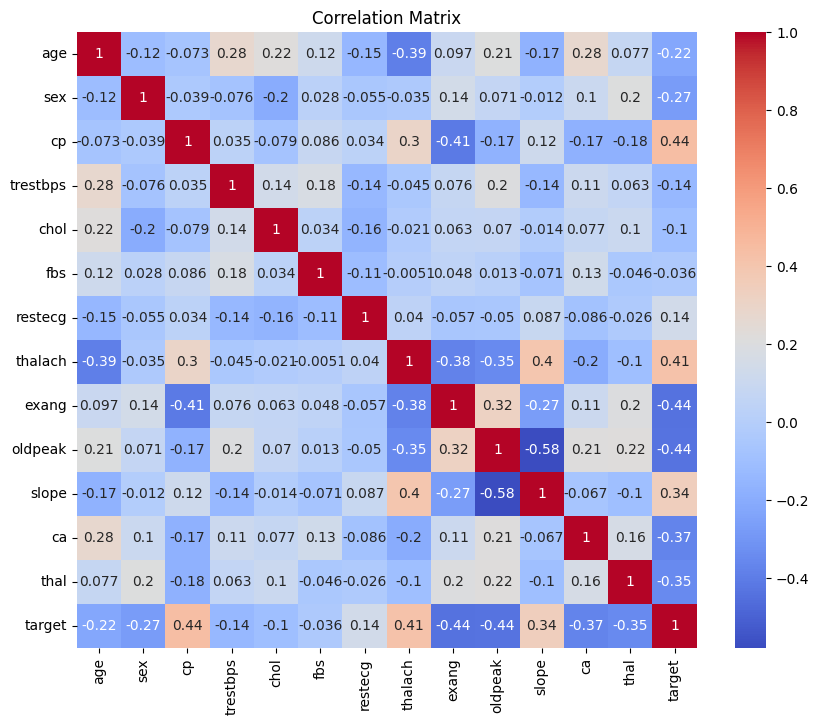


 Logistic Regression
Accuracy: 0.8402061855670103
ROC-AUC: 0.8421276595744681
              precision    recall  f1-score   support

           0       0.90      0.78      0.83       100
           1       0.79      0.90      0.85        94

    accuracy                           0.84       194
   macro avg       0.85      0.84      0.84       194
weighted avg       0.85      0.84      0.84       194

Confusion Matrix:
[[78 22]
 [ 9 85]]

 Random Forest
Accuracy: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        94

    accuracy                           1.00       194
   macro avg       1.00      1.00      1.00       194
weighted avg       1.00      1.00      1.00       194

Confusion Matrix:
[[100   0]
 [  0  94]]

Перші 10 прогнозів:
   Actual  Predicted_Logistic  Predicted_RF
0       0                   0             0
1       0                   0        

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

# 1.Вивести перших 5 рядків
df = pd.read_csv("heart.csv")

print("Перші 5 рядків:")
print(df.head())

# 2.Визначити розмір датасета
print("\nІнформація про датасет:")
print(df.info())

# 3.Визначити опис статистики
print("\nОписова статистика:")
print(df.describe())

# 4.Визначити пропущених значень, кількість дублікатів та назви колонок
print("\nПропуски:")
print(df.isnull().sum())

print("\nКількість дублікатів:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("\nНазви колонок:")
print(df.columns)

# 5. Визначення цільової змінної
target_column = "target"

df["target"] = (df["target"] > 0.5).astype(int)
print(df["target"].value_counts())

print("\nРозподіл цільової змінної:")
print(df[target_column].value_counts())
print("\nУ відсотках:")
print(df[target_column].value_counts(normalize=True) * 100)

# 6. Кореляційна матриця
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 7. Підготовка даних
X = df.drop(target_column, axis=1)
y = df[target_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 8. Логістична регресія
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# 9. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# 10. Порівняння фактичних і прогнозованих значень
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Logistic": y_pred_log,
    "Predicted_RF": y_pred_rf
})

print("\nПерші 10 прогнозів:")
print(comparison.head(10))

У ході виконання роботи було проведено статистичний аналіз датасету Heart Attack Prediction, що містить медичні показники пацієнтів та інформацію про ризик серцевого нападу.

Було перевірено структуру даних, встановлено відсутність пропущених значень, а також виявлено та видалено дублікати записів. Описова статистика показала середні значення основних медичних показників, таких як вік, артеріальний тиск, рівень холестерину та максимальна частота серцевих скорочень.

Аналіз розподілу цільової змінної дозволив оцінити баланс класів у вибірці. Кореляційний аналіз продемонстрував наявність зв’язку між ризиком серцевого нападу та такими показниками, як тип болю в грудях, максимальна частота пульсу, показник oldpeak та кількість уражених судин.

Було побудовано моделі машинного навчання (логістична регресія та випадковий ліс), які продемонстрували здатність передбачати ризик серцевого нападу з прийнятною точністю. Порівняння метрик якості показало, що модель випадкового лісу забезпечує кращу узагальнювальну здатність завдяки врахуванню нелінійних залежностей між ознаками.